# 스마트 창고 출고 지연 예측 v5

### v4 → v5 주요 개선사항
1. **누적/롤링 피처** : cumsum, roll3, expanding, slot_idx, trend
2. **pack_utilization 임계점** : >0.95 비선형 점프 포착
3. **레이아웃 클러스터** : 미확인 레이아웃 50개 대응
4. **타겟 변환 개선** : log1p → sqrt + MAE objective (예측 범위 확장)
5. **CatBoost Optuna 튜닝** 추가
6. **4-모델 앙상블** : sqrt 3개 + log1p 1개 (다양성 확보)
7. **Quantile Mapping 후처리** : 예측 분포 보정

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import warnings
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED    = 42
N_FOLDS = 5
TARGET  = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

np.random.seed(SEED)
print('✅ 환경 설정 완료')

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 환경 설정 완료


## 1. 데이터 로드 + 레이아웃 클러스터

In [2]:
train  = pd.read_csv('./data/train.csv')
test   = pd.read_csv('./data/test.csv')
layout = pd.read_csv('./data/layout_info.csv')

layout_type_map = {v: i for i, v in enumerate(layout['layout_type'].unique())}
layout['layout_type_enc'] = layout['layout_type'].map(layout_type_map)

# [v5] 레이아웃 클러스터 (미확인 레이아웃 대응)
layout_num_cols = [
    'aisle_width_avg', 'intersection_count', 'one_way_ratio',
    'pack_station_count', 'charger_count', 'layout_compactness',
    'zone_dispersion', 'robot_total', 'floor_area_sqm', 'ceiling_height_m'
]
scaler = StandardScaler()
layout_scaled = scaler.fit_transform(layout[layout_num_cols].fillna(0))
kmeans = KMeans(n_clusters=15, random_state=SEED, n_init=20)
layout['layout_cluster'] = kmeans.fit_predict(layout_scaled)

train = train.merge(layout.drop(columns=['layout_type']), on='layout_id', how='left')
test  = test.merge(layout.drop(columns=['layout_type']),  on='layout_id', how='left')

unseen = set(test['layout_id'].unique()) - set(train['layout_id'].unique())
print(f'train: {train.shape}, test: {test.shape}')
print(f'미확인 레이아웃: {len(unseen)}개')

train: (250000, 109), test: (50000, 108)
미확인 레이아웃: 50개


## 2. 타겟 분석

In [3]:
print('=== 타겟 통계 ===')
print(train[TARGET].describe())
print(f'왜도: 원본={stats.skew(train[TARGET]):.2f}, sqrt={stats.skew(np.sqrt(train[TARGET].clip(0))):.2f}, log1p={stats.skew(np.log1p(train[TARGET])):.2f}')

=== 타겟 통계 ===
count    250000.000000
mean         18.962296
std          27.351374
min           0.000000
25%           4.278801
50%           9.032652
75%          25.791869
max         715.858119
Name: avg_delay_minutes_next_30m, dtype: float64
왜도: 원본=5.68, sqrt=1.47, log1p=0.08


## 3. 피처 엔지니어링 (v5 확장)

In [4]:
def engineer_features(df):
    d = df.copy()
    # ── ① 로봇 압박 ──
    d['charge_pressure']       = d['charge_queue_length'] / (d['charger_count'] + 1)
    d['active_robot_ratio']    = d['robot_active'] / (d['robot_total'] + 1)
    d['idle_robot_ratio']      = d['robot_idle'] / (d['robot_total'] + 1)
    d['low_batt_robot_count']  = d['low_battery_ratio'] * d['robot_active']
    d['battery_stress']        = (1 - d['battery_mean'] / 100) * d['battery_std']
    d['charge_inefficiency']   = (100 - d['charge_efficiency_pct']) / 100
    d['effective_robot_avail'] = d['robot_total'] - d['low_batt_robot_count'] - d['charge_queue_length']
    d['robot_fault_ratio']     = d['fault_count_15m'] / (d['robot_active'] + 1)
    # ── ② 병목 복합 ──
    d['incident_total_15m']    = d['blocked_path_15m'] + d['near_collision_15m'] + d['fault_count_15m']
    d['congestion_load']       = d['congestion_score'] * d['avg_trip_distance']
    d['wait_per_intersection'] = d['intersection_wait_time_avg'] / (d['intersection_count'] + 1)
    d['path_congestion_gap']   = d['path_optimization_score'] - d['congestion_score']
    d['aisle_density']         = d['aisle_traffic_score'] / (d['aisle_width_avg'] + 0.1)
    d['oneway_congestion']     = d['one_way_ratio'] * d['congestion_score']
    d['compact_congestion']    = d['layout_compactness'] * d['congestion_score']
    # ── ③ 주문 부하 ──
    d['order_complexity']      = d['unique_sku_15m'] * d['avg_items_per_order']
    d['urgent_heavy_ratio']    = d['urgent_order_ratio'] * d['heavy_item_ratio']
    d['effective_order_load']  = d['order_inflow_15m'] * (1 + d['urgent_order_ratio'])
    d['rework_pressure']       = d['return_order_ratio'] + d['replenishment_overlap']
    d['forecast_miss']         = 1 - d['daily_forecast_accuracy']
    d['pick_complexity']       = d['pick_list_length_avg'] * (1 - d['sku_concentration'])
    d['backorder_urgency']     = d['backorder_ratio'] * d['urgent_order_ratio']
    # ── ④ 설비 압박 ──
    d['dock_pack_util_avg']      = (d['pack_utilization'] + d['loading_dock_util'] + d['staging_area_util']) / 3
    d['orders_per_pack_station'] = d['order_inflow_15m'] / (d['pack_station_count'] + 1)
    d['orders_per_robot']        = d['order_inflow_15m'] / (d['robot_active'] + 1)
    d['robot_density']           = d['robot_total'] / (d['floor_area_sqm'] + 1)
    d['charger_robot_ratio']     = d['charger_count'] / (d['robot_total'] + 1)
    d['pack_area_pressure']      = d['pack_utilization'] * d['layout_compactness']
    d['dock_truck_bottleneck']   = d['loading_dock_util'] * d['outbound_truck_wait_min']
    # ── ⑤ 환경/시스템 ──
    d['temp_diff']             = abs(d['warehouse_temp_avg'] - d['external_temp_c'])
    d['heat_humidity_index']   = d['warehouse_temp_avg'] * d['humidity_pct'] / 100
    d['it_bottleneck']         = d['wms_response_time_ms'] * (1 + d['scanner_error_rate'])
    d['network_instability']   = d['network_latency_ms'] * (1 - d['wifi_signal_db'] / 100)
    d['barcode_fail_rate']     = 1 - d['barcode_read_success_rate']
    d['label_scan_bottleneck'] = d['label_print_queue'] * (1 + d['scanner_error_rate'])
    d['conveyor_load']         = d['avg_package_weight_kg'] / (d['conveyor_speed_mps'] + 0.01)
    # ── ⑥ 인력 ──
    d['orders_per_staff']      = d['order_inflow_15m'] / (d['staff_on_floor'] + 1)
    d['forklift_staff_ratio']  = d['forklift_active_count'] / (d['staff_on_floor'] + 1)
    d['shift_load_ratio']      = d['order_inflow_15m'] / (d['prev_shift_volume'] + 1)
    d['handover_pressure']     = d['shift_handover_delay_min'] * d['prev_shift_volume'] / 1000
    d['skilled_capacity']      = d['staff_on_floor'] * d['worker_avg_tenure_months']
    # ── ⑦ 시간 ──
    d['shift_hour_sin'] = np.sin(2 * np.pi * d['shift_hour'] / 24)
    d['shift_hour_cos'] = np.cos(2 * np.pi * d['shift_hour'] / 24)
    d['dow_sin']        = np.sin(2 * np.pi * d['day_of_week'] / 7)
    d['dow_cos']        = np.cos(2 * np.pi * d['day_of_week'] / 7)
    d['is_peak_hour']   = d['shift_hour'].isin([9,10,11,14,15,16,17]).astype(int)
    # ── ⑧ 레이아웃 ──
    d['age_maintenance_risk']    = d['building_age_years'] * (1 - d['maintenance_schedule_score'])
    d['vertical_gap']            = d['ceiling_height_m'] - d['racking_height_avg_m']
    d['dispersion_trip_cost']    = d['zone_dispersion'] * d['avg_trip_distance']
    d['crossdock_dock_pressure'] = d['cross_dock_ratio'] * d['loading_dock_util']
    d['cold_chain_risk']         = d['cold_chain_ratio'] * abs(d['cold_storage_temp_c'] + 18)
    d['area_per_robot']          = d['floor_area_sqm'] / (d['robot_total'] + 1)
    # ── ⑨ 교호 ──
    d['robot_order_congestion']  = d['orders_per_robot'] * d['congestion_score']
    d['battery_order_pressure']  = d['battery_stress'] * d['effective_order_load']
    d['it_order_bottleneck']     = d['it_bottleneck'] * d['order_inflow_15m'] / 1000
    d['super_traffic_jam_risk']  = d['sku_concentration'] * d['avg_trip_distance'] * d['layout_compactness']
    # ═══ [v5 NEW] ═══
    # ⑩ pack 비선형 임계점
    d['pack_saturated']         = (d['pack_utilization'] > 0.95).astype(int)
    d['pack_overflow_pressure'] = np.maximum(d['pack_utilization'] - 0.95, 0) * d['order_inflow_15m']
    d['pack_util_sq']           = d['pack_utilization'] ** 2
    d['pack_sat_x_orders']      = d['pack_saturated'] * d['orders_per_pack_station']
    d['pack_sat_x_congestion']  = d['pack_saturated'] * d['congestion_score']
    # ⑪ 레이아웃 교호 추가
    d['pack_station_x_compact']    = d['pack_station_count'] * d['layout_compactness']
    d['intersection_x_dispersion'] = d['intersection_count'] * d['zone_dispersion']
    d['robot_per_pack_station']    = d['robot_total'] / (d['pack_station_count'] + 1)
    d['charger_per_area']          = d['charger_count'] / (d['floor_area_sqm'] / 1000 + 1)
    # ⑫ 늦은 시간대
    d['is_late_peak']       = (d['shift_hour'] >= 18).astype(int)
    d['late_peak_x_order']  = d['is_late_peak'] * d['order_inflow_15m']
    d['late_peak_x_pack']   = d['is_late_peak'] * d['pack_utilization']
    # ⑬ 추가 교호
    d['order_per_robot_sq']    = d['orders_per_robot'] ** 2
    d['low_batt_x_congestion'] = d['low_battery_ratio'] * d['congestion_score']
    d['idle_x_order_load']     = d['idle_robot_ratio'] * d['effective_order_load']
    d['charge_q_x_orders']     = d['charge_queue_length'] * d['order_inflow_15m']
    d['robot_util_x_trip']     = d['robot_utilization'] * d['avg_trip_distance']
    return d

train_fe = engineer_features(train)
test_fe  = engineer_features(test)
print(f'피처 엔지니어링: {train_fe.shape}')

피처 엔지니어링: (250000, 182)


## 4. 래그 + 누적/롤링 피처 (v5)

In [5]:
LAG_COLS = [
    'order_inflow_15m', 'congestion_score', 'robot_active', 'robot_utilization',
    'battery_mean', 'charge_queue_length', 'blocked_path_15m', 'fault_count_15m',
    'pack_utilization', 'loading_dock_util', 'effective_order_load',
    'congestion_load', 'charge_pressure', 'orders_per_robot',
    'it_bottleneck', 'battery_stress',
]
CUM_COLS = ['order_inflow_15m','congestion_score','blocked_path_15m','fault_count_15m','near_collision_15m','incident_total_15m']
ROLL_COLS = ['order_inflow_15m','congestion_score','battery_mean','pack_utilization','robot_utilization','effective_order_load','loading_dock_util']

def add_temporal_features(df, lag_cols, cum_cols, roll_cols):
    d = df.copy().sort_values(['scenario_id','shift_hour']).reset_index(drop=True)
    # slot position
    d['slot_idx'] = d.groupby('scenario_id').cumcount()
    d['slot_progress'] = d['slot_idx'] / 24
    # lags
    for col in lag_cols:
        if col not in d.columns: continue
        l1 = d.groupby('scenario_id')[col].shift(1)
        l2 = d.groupby('scenario_id')[col].shift(2)
        d[f'{col}_lag1'] = l1
        d[f'{col}_lag2'] = l2
        d[f'{col}_diff1'] = d[col] - l1
    # cumsum
    for col in cum_cols:
        if col not in d.columns: continue
        d[f'{col}_cumsum'] = d.groupby('scenario_id')[col].cumsum()
    # rolling
    for col in roll_cols:
        if col not in d.columns: continue
        d[f'{col}_roll3_mean'] = d.groupby('scenario_id')[col].transform(lambda x: x.rolling(3, min_periods=1).mean())
        d[f'{col}_roll3_std']  = d.groupby('scenario_id')[col].transform(lambda x: x.rolling(3, min_periods=1).std())
    # expanding mean
    for col in ['order_inflow_15m','congestion_score','pack_utilization','battery_mean']:
        if col not in d.columns: continue
        d[f'{col}_exp_mean'] = d.groupby('scenario_id')[col].transform(lambda x: x.expanding().mean())
    # trend (3-slot slope)
    for col in ['order_inflow_15m','congestion_score','pack_utilization']:
        if col not in d.columns: continue
        def rolling_slope(x):
            out = np.full(len(x), np.nan); vals = x.values
            for i in range(2, len(vals)):
                y_v = vals[i-2:i+1]
                if np.all(np.isfinite(y_v)): out[i] = (y_v[2] - y_v[0]) / 2
            return pd.Series(out, index=x.index)
        d[f'{col}_trend3'] = d.groupby('scenario_id')[col].transform(rolling_slope)
    # pack lag thresholds
    if 'pack_utilization_lag1' in d.columns:
        d['pack_sat_lag1'] = (d['pack_utilization_lag1'] > 0.95).astype(int)
    if 'pack_utilization_lag2' in d.columns:
        d['pack_sat_lag2'] = (d['pack_utilization_lag2'] > 0.95).astype(int)
    # cumulative interactions
    if 'order_inflow_15m_cumsum' in d.columns:
        d['cum_order_per_robot'] = d['order_inflow_15m_cumsum'] / (d['robot_total'] + 1)
        d['cum_order_x_pack']   = d['order_inflow_15m_cumsum'] * d['pack_utilization']
    # fill NaN
    fill_cols = [c for c in d.columns if any(t in c for t in ['_lag','_diff','_cumsum','_roll3','_exp_','_trend','_sat_lag'])]
    for col in fill_cols:
        d[col] = d.groupby('scenario_id')[col].transform(lambda x: x.fillna(x.median()))
    d[fill_cols] = d[fill_cols].fillna(0)
    return d

train_fe = add_temporal_features(train_fe, LAG_COLS, CUM_COLS, ROLL_COLS)
test_fe  = add_temporal_features(test_fe,  LAG_COLS, CUM_COLS, ROLL_COLS)
print(f'전체 피처: {len([c for c in train_fe.columns if c not in ID_COLS + [TARGET]])}')

전체 피처: 259


## 4.5 [v5.2 NEW] 시나리오 전체 통계 피처
같은 시나리오 25개 슬롯의 X피처를 집계 (mean/std/max).
시나리오 간 분산(전체의 63%)을 포착하는 핵심 피처 — 기존 최고 상관 0.37 → 0.42

In [6]:
# [v5.2] 시나리오 전체 통계 피처
# 같은 시나리오의 모든 25개 슬롯을 집계 → '이 시나리오의 전반적 성격' 포착
# test에서도 동일하게 생성 가능 (X 피처만 사용, 타겟 미사용)

SC_COLS = [
    'order_inflow_15m', 'congestion_score', 'robot_utilization', 'battery_mean',
    'pack_utilization', 'loading_dock_util', 'blocked_path_15m', 'fault_count_15m',
    'low_battery_ratio', 'charge_queue_length', 'robot_idle', 'near_collision_15m',
]

def add_scenario_stats(df, cols):
    d = df.copy()
    for col in cols:
        if col not in d.columns:
            continue
        d[f'sc_{col}_mean'] = d.groupby('scenario_id')[col].transform('mean')
        d[f'sc_{col}_std']  = d.groupby('scenario_id')[col].transform('std')
        d[f'sc_{col}_max']  = d.groupby('scenario_id')[col].transform('max')
    # 시나리오 내 전반부 vs 후반부 차이 (추세 방향)
    d_sorted = d.sort_values(['scenario_id', 'shift_hour'])
    d['_slot'] = d_sorted.groupby('scenario_id').cumcount().values
    for col in ['order_inflow_15m', 'congestion_score', 'robot_utilization']:
        if col not in d.columns:
            continue
        first_half = d[d['_slot'] < 12].groupby('scenario_id')[col].mean()
        second_half = d[d['_slot'] >= 12].groupby('scenario_id')[col].mean()
        half_diff = (second_half - first_half).rename(f'sc_{col}_half_diff')
        d = d.merge(half_diff.reset_index(), on='scenario_id', how='left')
    d = d.drop(columns=['_slot'])
    # NaN 처리
    sc_feat_cols = [c for c in d.columns if c.startswith('sc_')]
    d[sc_feat_cols] = d[sc_feat_cols].fillna(0)
    return d

train_fe = add_scenario_stats(train_fe, SC_COLS)
test_fe  = add_scenario_stats(test_fe, SC_COLS)

sc_count = len([c for c in train_fe.columns if c.startswith('sc_')])
print(f'시나리오 통계 피처 추가: {sc_count}개')
print(f'전체 피처 수: {len([c for c in train_fe.columns if c not in ID_COLS + [TARGET]])}')

시나리오 통계 피처 추가: 39개
전체 피처 수: 298


## 5. 타겟 인코딩

In [7]:
def target_encode_cv(train_df, test_df, col, target, n_splits=5, alpha=20):
    gm = train_df[target].mean(); enc = np.zeros(len(train_df))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    for ti, vi in kf.split(train_df):
        s = train_df.iloc[ti].groupby(col)[target].agg(['mean','count'])
        s['sm'] = (s['count']*s['mean']+alpha*gm)/(s['count']+alpha)
        enc[vi] = train_df.iloc[vi][col].map(s['sm']).fillna(gm)
    fs = train_df.groupby(col)[target].agg(['mean','count'])
    fs['sm'] = (fs['count']*fs['mean']+alpha*gm)/(fs['count']+alpha)
    te = test_df[col].map(fs['sm']).fillna(gm).values
    return enc, te

for col_name, feat_name in [('layout_id','te_layout_id'),('layout_type_enc','te_layout_type'),('layout_cluster','te_layout_cluster')]:
    tr_e, te_e = target_encode_cv(train_fe, test_fe, col_name, TARGET)
    train_fe[feat_name] = tr_e
    test_fe[feat_name]  = te_e
print('✅ 타겟 인코딩 완료 (layout_id, layout_type, layout_cluster)')

✅ 타겟 인코딩 완료 (layout_id, layout_type, layout_cluster)


## 6. 피처/타겟 준비

In [8]:
feature_cols = [c for c in train_fe.columns if c not in ID_COLS + [TARGET]]
for col in feature_cols:
    med = train_fe[col].median()
    train_fe[col] = train_fe[col].fillna(med)
    test_fe[col]  = test_fe[col].fillna(med)

X, y, X_test = train_fe[feature_cols].copy(), train_fe[TARGET].copy(), test_fe[feature_cols].copy()
y_tr_sqrt = np.sqrt(y.clip(lower=0))
y_tr_log  = np.log1p(y.clip(lower=0))

def decode_sqrt(p): return (p.clip(0))**2
def decode_log(p):  return np.expm1(p).clip(0)

gkf    = GroupKFold(n_splits=N_FOLDS)
groups = train_fe['scenario_id']
print(f'피처: {len(feature_cols)}, 왜도: 원본={stats.skew(y):.2f} → sqrt={stats.skew(y_tr_sqrt):.2f}')

피처: 301, 왜도: 원본=5.68 → sqrt=1.47


## 7. LGB Optuna 튜닝 (sqrt+MAE)

In [9]:
tidx = np.random.choice(len(X), 50000, replace=False)
Xt, yt_s, yt_r, gt = X.iloc[tidx].reset_index(drop=True), y_tr_sqrt.iloc[tidx].reset_index(drop=True), y.iloc[tidx].reset_index(drop=True), groups.iloc[tidx].reset_index(drop=True)

def lgb_obj(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators',500,3000), learning_rate=trial.suggest_float('learning_rate',0.01,0.1,log=True),
             max_depth=trial.suggest_int('max_depth',4,9), num_leaves=trial.suggest_int('num_leaves',31,255),
             subsample=trial.suggest_float('subsample',0.5,1.0), colsample_bytree=trial.suggest_float('colsample_bytree',0.4,1.0),
             reg_alpha=trial.suggest_float('reg_alpha',1e-4,10,log=True), reg_lambda=trial.suggest_float('reg_lambda',1e-4,10,log=True),
             min_child_samples=trial.suggest_int('min_child_samples',20,200))
    F = dict(objective='mae', device='gpu', random_state=SEED, verbose=-1)
    ms = []
    for ti, vi in GroupKFold(n_splits=3).split(Xt, yt_s, groups=gt):
        m = LGBMRegressor(**p, **F)
        m.fit(Xt.iloc[ti], yt_s.iloc[ti], eval_set=[(Xt.iloc[vi], yt_s.iloc[vi])], callbacks=[lgb.early_stopping(30,verbose=False), lgb.log_evaluation(-1)])
        ms.append(mean_absolute_error(yt_r.iloc[vi], decode_sqrt(m.predict(Xt.iloc[vi]))))
    return np.mean(ms)

print('🔍 LGB Optuna (50 trials)...')
study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_obj, n_trials=50, show_progress_bar=True)
BEST_LGB = study_lgb.best_params
print(f'✅ LGB 최적 MAE: {study_lgb.best_value:.4f}')

🔍 LGB Optuna (50 trials)...


Best trial: 26. Best value: 8.85401: 100%|██████████| 50/50 [40:04<00:00, 48.09s/it]

✅ LGB 최적 MAE: 8.8540


## 8. [v5] CatBoost Optuna 튜닝

In [10]:
def cb_obj(trial):
    # 수정됨: colsample_bylevel 파라미터 제거
    p = dict(
        iterations=trial.suggest_int('iterations', 500, 3000), 
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        depth=trial.suggest_int('depth', 5, 10), 
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 0.1, 20, log=True),
        subsample=trial.suggest_float('subsample', 0.5, 1.0), 
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 10, 200)
    )
    F = dict(loss_function='MAE', eval_metric='MAE', bootstrap_type='Bernoulli', 
             random_seed=SEED, early_stopping_rounds=30, verbose=0, 
             task_type='GPU', devices='0')
    ms = []
    for ti, vi in GroupKFold(n_splits=3).split(Xt, yt_s, groups=gt):
        m = CatBoostRegressor(**p, **F)
        m.fit(Xt.iloc[ti], yt_s.iloc[ti], eval_set=(Xt.iloc[vi], yt_s.iloc[vi]))
        ms.append(mean_absolute_error(yt_r.iloc[vi], decode_sqrt(m.predict(Xt.iloc[vi]))))
    return np.mean(ms)

print('🔍 CB Optuna (30 trials)...')
study_cb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cb.optimize(cb_obj, n_trials=30, show_progress_bar=True)
BEST_CB = study_cb.best_params
print(f'✅ CB 최적 MAE: {study_cb.best_value:.4f}')

🔍 CB Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Best trial: 0. Best value: 8.91667:   3%|▎         | 1/30 [02:06<1:00:59, 126.19s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Best trial: 0. Best value: 8.91667:   7%|▋         | 2/30 [03:39<49:47, 106.70s/it]  Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Best trial: 0. Best value: 8.91667:  10%|█         | 3/30 [06:10<57:07, 126.96s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default m

✅ CB 최적 MAE: 8.8892


## 9. LGB 5-Fold (sqrt)

In [11]:
oof_lgb, test_lgb, lgb_imp = np.zeros(len(X)), np.zeros(len(X_test)), np.zeros(len(feature_cols))
print('🚀 LGB 5-Fold (sqrt+MAE)\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1} ──')
    m = LGBMRegressor(**BEST_LGB, objective='mae', device='gpu', random_state=SEED, verbose=-1)
    m.fit(X.iloc[ti], y_tr_sqrt.iloc[ti], eval_set=[(X.iloc[vi], y_tr_sqrt.iloc[vi])],
          callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(200)])
    oof_lgb[vi] = decode_sqrt(m.predict(X.iloc[vi]))
    test_lgb   += decode_sqrt(m.predict(X_test)) / N_FOLDS
    lgb_imp    += m.feature_importances_ / N_FOLDS
    print(f'   MAE: {mean_absolute_error(y.iloc[vi], oof_lgb[vi]):.4f}\n')
print(f'📊 LGB(sqrt) OOF MAE: {mean_absolute_error(y, oof_lgb):.4f}')

🚀 LGB 5-Fold (sqrt+MAE)

── Fold 1 ──
[200]	valid_0's l1: 0.925288
[400]	valid_0's l1: 0.919386
   MAE: 8.8198

── Fold 2 ──
[200]	valid_0's l1: 0.929157
   MAE: 8.7851

── Fold 3 ──
[200]	valid_0's l1: 0.974141
   MAE: 9.3096

── Fold 4 ──
[200]	valid_0's l1: 0.896974
   MAE: 8.3062

── Fold 5 ──
[200]	valid_0's l1: 0.914373
[400]	valid_0's l1: 0.907696
   MAE: 8.6718

📊 LGB(sqrt) OOF MAE: 8.7785


## 10. CB 5-Fold (sqrt, 튜닝)

In [12]:
oof_cb, test_cb = np.zeros(len(X)), np.zeros(len(X_test))
print('🐱 CB 5-Fold (sqrt+MAE)\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1} ──')
    m = CatBoostRegressor(**BEST_CB, loss_function='MAE', eval_metric='MAE', bootstrap_type='Bernoulli',
                          random_seed=SEED, early_stopping_rounds=50, verbose=200, task_type='GPU', devices='0')
    m.fit(X.iloc[ti], y_tr_sqrt.iloc[ti], eval_set=(X.iloc[vi], y_tr_sqrt.iloc[vi]))
    oof_cb[vi] = decode_sqrt(m.predict(X.iloc[vi]))
    test_cb   += decode_sqrt(m.predict(X_test)) / N_FOLDS
    print(f'   MAE: {mean_absolute_error(y.iloc[vi], oof_cb[vi]):.4f}\n')
print(f'📊 CB(sqrt) OOF MAE: {mean_absolute_error(y, oof_cb):.4f}')

🐱 CB 5-Fold (sqrt+MAE)

── Fold 1 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7052111	test: 1.7089150	best: 1.7089150 (0)	total: 18.5ms	remaining: 39s
200:	learn: 0.8873923	test: 0.9372483	best: 0.9372483 (200)	total: 3.37s	remaining: 32s
400:	learn: 0.7966001	test: 0.9279918	best: 0.9279634 (399)	total: 6.75s	remaining: 28.7s
600:	learn: 0.7269923	test: 0.9249110	best: 0.9249055 (598)	total: 10.2s	remaining: 25.6s
bestTest = 0.9245742188
bestIteration = 629
Shrink model to first 630 iterations.
   MAE: 8.8666

── Fold 2 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7076097	test: 1.7006895	best: 1.7006895 (0)	total: 16.1ms	remaining: 34s
200:	learn: 0.8840624	test: 0.9353045	best: 0.9353045 (200)	total: 3.46s	remaining: 32.8s
bestTest = 0.9300404688
bestIteration = 283
Shrink model to first 284 iterations.
   MAE: 8.8359

── Fold 3 ──


...

0:	learn: 1.7029319	test: 1.7202555	best: 1.7202555 (0)	total: 15.7ms	remaining: 33s
200:	learn: 0.8726290	test: 0.9925834	best: 0.9925834 (200)	total: 3.34s	remaining: 31.7s
400:	learn: 0.7827488	test: 0.9812317	best: 0.9812317 (400)	total: 6.74s	remaining: 28.7s
600:	learn: 0.7112543	test: 0.9755477	best: 0.9755477 (600)	total: 10.2s	remaining: 25.7s
bestTest = 0.975330625
bestIteration = 616
Shrink model to first 617 iterations.
   MAE: 9.3415

── Fold 4 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7076392	test: 1.6999414	best: 1.6999414 (0)	total: 15.9ms	remaining: 33.5s
200:	learn: 0.8960942	test: 0.9070110	best: 0.9070110 (200)	total: 3.42s	remaining: 32.4s
400:	learn: 0.8060098	test: 0.8964801	best: 0.8964801 (400)	total: 6.88s	remaining: 29.3s
600:	learn: 0.7305441	test: 0.8952532	best: 0.8949481 (569)	total: 10.4s	remaining: 26.1s
bestTest = 0.894948125
bestIteration = 569
Shrink model to first 570 iterations.
   MAE: 8.3332

── Fold 5 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7070123	test: 1.7030839	best: 1.7030839 (0)	total: 17.1ms	remaining: 35.9s
200:	learn: 0.8898709	test: 0.9179773	best: 0.9179773 (200)	total: 3.45s	remaining: 32.7s
400:	learn: 0.8028084	test: 0.9116823	best: 0.9114029 (388)	total: 6.75s	remaining: 28.7s
600:	learn: 0.7277177	test: 0.9092448	best: 0.9089888 (589)	total: 10.2s	remaining: 25.6s
bestTest = 0.9086423437
bestIteration = 669
Shrink model to first 670 iterations.
   MAE: 8.6806

📊 CB(sqrt) OOF MAE: 8.8116


## 11. XGB 5-Fold (sqrt)

In [13]:
oof_xgb, test_xgb = np.zeros(len(X)), np.zeros(len(X_test))
print('⚡ XGB 5-Fold (sqrt+MAE)\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1} ──')
    m = XGBRegressor(n_estimators=3000, learning_rate=0.03, max_depth=8, subsample=0.8, colsample_bytree=0.7,
                     reg_alpha=0.1, reg_lambda=1.0, tree_method='hist', device='cuda',
                     random_state=SEED, verbosity=0, early_stopping_rounds=100, eval_metric='mae')
    m.fit(X.iloc[ti], y_tr_sqrt.iloc[ti], eval_set=[(X.iloc[vi], y_tr_sqrt.iloc[vi])], verbose=200)
    oof_xgb[vi] = decode_sqrt(m.predict(X.iloc[vi]))
    test_xgb   += decode_sqrt(m.predict(X_test)) / N_FOLDS
    print(f'   MAE: {mean_absolute_error(y.iloc[vi], oof_xgb[vi]):.4f}\n')
print(f'📊 XGB(sqrt) OOF MAE: {mean_absolute_error(y, oof_xgb):.4f}')

⚡ XGB 5-Fold (sqrt+MAE)

── Fold 1 ──
[0]	validation_0-mae:1.77313
[200]	validation_0-mae:0.91948
[245]	validation_0-mae:0.92001
   MAE: 8.7858

── Fold 2 ──
[0]	validation_0-mae:1.75687
[200]	validation_0-mae:0.93132
[262]	validation_0-mae:0.93164
   MAE: 8.8813

── Fold 3 ──
[0]	validation_0-mae:1.75634
[200]	validation_0-mae:0.97908
[251]	validation_0-mae:0.97876
   MAE: 9.4026

── Fold 4 ──
[0]	validation_0-mae:1.76649
[200]	validation_0-mae:0.89225
[400]	validation_0-mae:0.89266
[418]	validation_0-mae:0.89290
   MAE: 8.3146

── Fold 5 ──
[0]	validation_0-mae:1.77055
[200]	validation_0-mae:0.91773
[273]	validation_0-mae:0.91765
   MAE: 8.7655

📊 XGB(sqrt) OOF MAE: 8.8300


## 12. [v5] LGB (log1p) — 다양성

In [14]:
oof_lgb_log, test_lgb_log = np.zeros(len(X)), np.zeros(len(X_test))
print('🔄 LGB(log1p) 5-Fold\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    m = LGBMRegressor(**BEST_LGB, objective='mae', device='gpu', random_state=SEED+1, verbose=-1)
    m.fit(X.iloc[ti], y_tr_log.iloc[ti], eval_set=[(X.iloc[vi], y_tr_log.iloc[vi])],
          callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(-1)])
    oof_lgb_log[vi] = decode_log(m.predict(X.iloc[vi]))
    test_lgb_log   += decode_log(m.predict(X_test)) / N_FOLDS
    print(f'  Fold {fold+1} MAE: {mean_absolute_error(y.iloc[vi], oof_lgb_log[vi]):.4f}')
print(f'\n📊 LGB(log) OOF MAE: {mean_absolute_error(y, oof_lgb_log):.4f}')

🔄 LGB(log1p) 5-Fold

  Fold 1 MAE: 8.7973
  Fold 2 MAE: 8.7644
  Fold 3 MAE: 9.2733
  Fold 4 MAE: 8.3176
  Fold 5 MAE: 8.6424

📊 LGB(log) OOF MAE: 8.7590


## 13. 4-모델 앙상블

In [15]:
def ens_loss(w):
    return mean_absolute_error(y, w[0]*oof_lgb + w[1]*oof_cb + w[2]*oof_xgb + w[3]*oof_lgb_log)

res = minimize(ens_loss, [.3,.3,.2,.2], method='SLSQP', bounds=[(0,1)]*4,
               constraints={'type':'eq','fun':lambda w:sum(w)-1})
w_lgb, w_cb, w_xgb, w_log = res.x
lgb_m = mean_absolute_error(y, oof_lgb)
cb_m  = mean_absolute_error(y, oof_cb)
xgb_m = mean_absolute_error(y, oof_xgb)
log_m = mean_absolute_error(y, oof_lgb_log)
print(f'가중치: LGB={w_lgb:.3f} CB={w_cb:.3f} XGB={w_xgb:.3f} LOG={w_log:.3f}')
print(f'\n  LGB(sqrt): {lgb_m:.4f}\n  CB(sqrt):  {cb_m:.4f}\n  XGB(sqrt): {xgb_m:.4f}\n  LGB(log):  {log_m:.4f}')
print(f'  앙상블:     {res.fun:.4f}')

가중치: LGB=0.000 CB=0.123 XGB=0.314 LOG=0.564

  LGB(sqrt): 8.7785
  CB(sqrt):  8.8116
  XGB(sqrt): 8.8300
  LGB(log):  8.7590
  앙상블:     8.7298


## 14. [v5] Quantile Mapping 후처리

In [16]:
raw_test = (w_lgb*test_lgb + w_cb*test_cb + w_xgb*test_xgb + w_log*test_lgb_log).clip(0)
oof_bl   = (w_lgb*oof_lgb + w_cb*oof_cb + w_xgb*oof_xgb + w_log*oof_lgb_log).clip(0)

qs = np.arange(0.01, 1.00, 0.01)
q_true, q_pred = np.quantile(y, qs), np.quantile(oof_bl, qs)

for p in [.50,.75,.90,.95,.99]:
    i = int(p*100)-1
    print(f'  {p:.0%}: 실제={q_true[i]:.1f}, 예측={q_pred[i]:.1f}')

oof_mapped = np.interp(oof_bl, q_pred, q_true)
mae_bef = mean_absolute_error(y, oof_bl)
mae_aft = mean_absolute_error(y, oof_mapped)
print(f'\nQM 효과: {mae_bef:.4f} → {mae_aft:.4f} ({mae_aft-mae_bef:+.4f})')

if mae_aft < mae_bef:
    final_preds = np.interp(raw_test, q_pred, q_true).clip(0)
    print('✅ QM 적용')
else:
    final_preds = raw_test
    print('⚠️ QM 미적용')

  50%: 실제=9.0, 예측=8.8
  75%: 실제=25.8, 예측=30.6
  90%: 실제=45.2, 예측=35.8
  95%: 실제=60.8, 예측=38.1
  99%: 실제=120.9, 예측=44.4

QM 효과: 8.7298 → 10.2003 (+1.4705)
⚠️ QM 미적용


## 15. Feature Importance

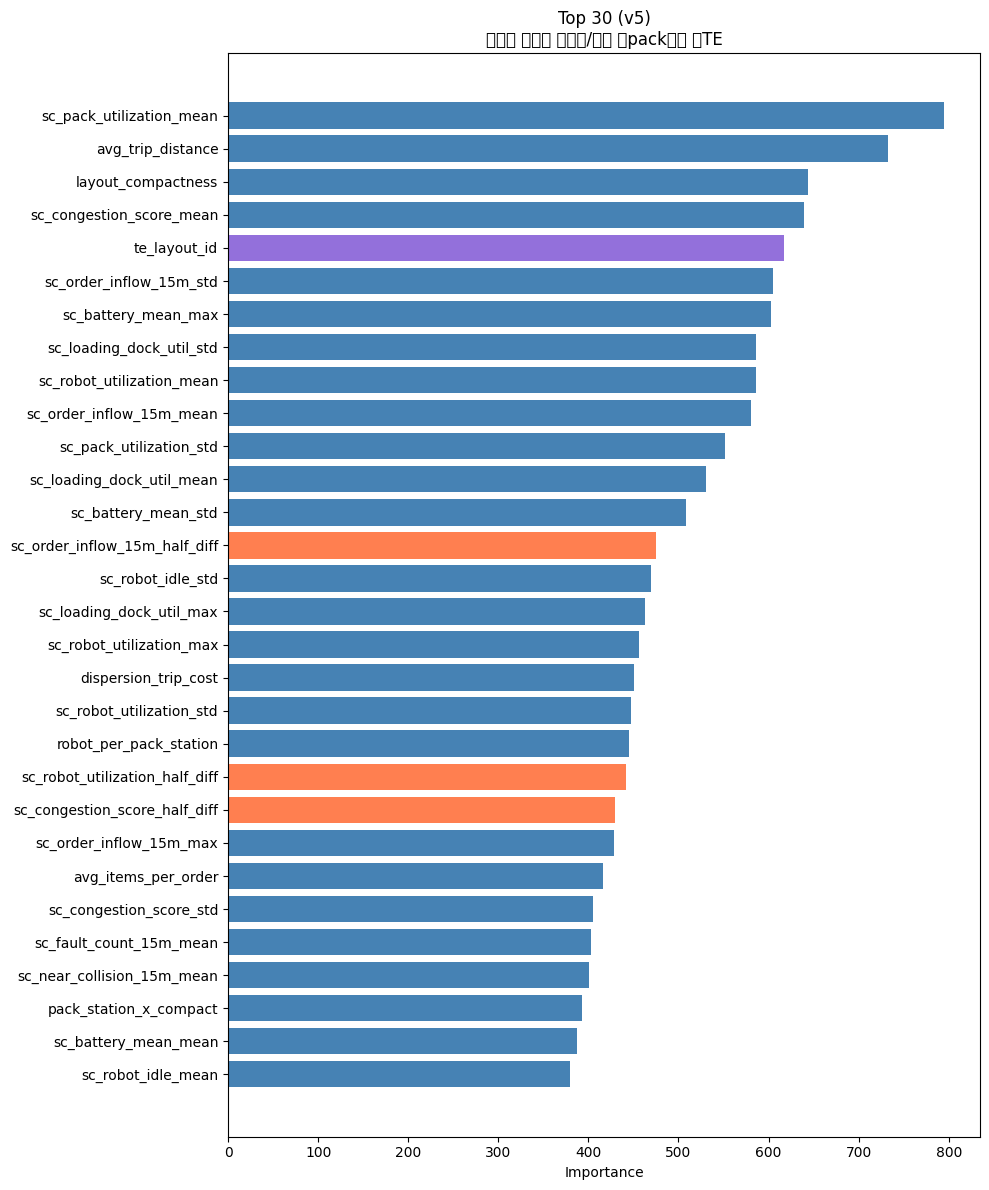

                      feature  importance
     sc_pack_utilization_mean       795.0
            avg_trip_distance       732.2
           layout_compactness       644.0
     sc_congestion_score_mean       639.0
                 te_layout_id       616.8
      sc_order_inflow_15m_std       604.6
          sc_battery_mean_max       603.2
     sc_loading_dock_util_std       586.6
    sc_robot_utilization_mean       585.6
     sc_order_inflow_15m_mean       580.0
      sc_pack_utilization_std       552.2
    sc_loading_dock_util_mean       530.2
          sc_battery_mean_std       508.2
sc_order_inflow_15m_half_diff       475.6
            sc_robot_idle_std       469.4


In [17]:
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': lgb_imp}).sort_values('importance', ascending=False).reset_index(drop=True)
top30 = imp_df.head(30)
def gc(n):
    if '_lag' in n or '_diff' in n: return 'coral'
    if any(t in n for t in ['_cumsum','_roll3','_exp_','_trend','slot_']): return 'mediumseagreen'
    if 'pack_sat' in n or 'pack_overflow' in n or 'pack_util_sq' in n: return 'gold'
    if 'te_' in n: return 'mediumpurple'
    return 'steelblue'
fig, ax = plt.subplots(figsize=(10,12))
ax.barh(top30['feature'][::-1], top30['importance'][::-1], color=top30['feature'].map(gc)[::-1])
ax.set_xlabel('Importance'); ax.set_title('Top 30 (v5)\n🔵원본 🟠래그 🟢누적/롤링 🟡pack임계 🟣TE')
plt.tight_layout(); plt.savefig('./feature_importance_v5.png', dpi=150, bbox_inches='tight'); plt.show()
print(imp_df.head(15)[['feature','importance']].to_string(index=False))

## 16. 제출

In [18]:
sub = pd.read_csv('./data/sample_submission.csv').drop(columns=[TARGET], errors='ignore')
sub = sub.merge(pd.DataFrame({'ID': test_fe['ID'], TARGET: final_preds}), on='ID', how='left')
sub.to_csv('./submission_v5.csv', index=False)
print('✅ submission_v5.csv 저장')
print(sub[TARGET].describe())
print(f'\n  v4 max ~51  → v5 max {final_preds.max():.1f}')
print(f'  v4 95% ~37  → v5 95% {np.percentile(final_preds,95):.1f}')
print(f'  v4 99% ~41  → v5 99% {np.percentile(final_preds,99):.1f}')

✅ submission_v5.csv 저장
count    50000.000000
mean        19.321675
std         14.081923
min          0.252471
25%          5.623393
50%         14.969917
75%         33.707680
max         84.732285
Name: avg_delay_minutes_next_30m, dtype: float64

  v4 max ~51  → v5 max 84.7
  v4 95% ~37  → v5 95% 39.2
  v4 99% ~41  → v5 99% 46.7
